In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm
import json

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

# Keras / TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

DATA_DIR = Path("/Users/jean-christophebertincourt/Desktop/Prise mouvement")

**Vérification dossier :**

In [14]:
print(f'Existe : {DATA_DIR.exists()}')
print(f'Dossiers dedans : {sorted([f.name for f in DATA_DIR.iterdir() if f.is_dir()])}')

Existe : True
Dossiers dedans : ['mouvement_1', 'mouvement_10', 'mouvement_11', 'mouvement_12', 'mouvement_13', 'mouvement_14', 'mouvement_15', 'mouvement_16', 'mouvement_17', 'mouvement_18', 'mouvement_2', 'mouvement_3', 'mouvement_4', 'mouvement_5', 'mouvement_6', 'mouvement_7', 'mouvement_8', 'mouvement_9']


**Création dictionnaire :**

In [18]:
my_signes = {
    'mouvement_1':  'aider',
    'mouvement_2':  'ameliorer',
    'mouvement_3':  'ami',
    'mouvement_4':  "aujourd'hui",
    'mouvement_5':  'bonjour',
    'mouvement_6':  'communiquer',
    'mouvement_7':  'entendant',
    'mouvement_8':  'content',
    'mouvement_9':  'je_suis',
    'mouvement_10': 'je_veux',
    'mouvement_11': 'langue_des_signes',
    'mouvement_12': 'merci',
    'mouvement_13': 'outil_pointage',
    'mouvement_14': 'outil',
    'mouvement_15': 'presenter',
    'mouvement_16': 'projet',
    'mouvement_17': 'sourd_pointage',
    'mouvement_18': 'sourde',
}


signs_list = list(my_signes.values())
sign_to_idx = {sign: i for i, sign in enumerate(signs_list)}
idx_to_sign = {i: sign for sign, i in sign_to_idx.items()}

print(f'Nombre de signes : {len(my_signes)}')

Nombre de signes : 18


Défini X et Y :

In [19]:
X_list = []
y_list = []

for mouvement_name, sign_name in tqdm(my_signes.items(), desc='Chargement'):
    # 1. Récupérer le numéro de classe correspondant au signe
    label = sign_to_idx[sign_name]
    
    # 2. Construire le chemin du dossier
    folder = DATA_DIR / mouvement_name
    
    # 3. Récupérer tous les .npy du dossier
    npy_files = folder.glob('*.npy')
    
    # 4. Boucle sur chaque fichier
    for npy_file in npy_files:
        data = np.load(npy_file).astype(np.float32)
        X_list.append(data)
        y_list.append(label)

# Conversion en arrays numpy
X = np.array(X_list)
y = np.array(y_list)

print(f'\nShape de X : {X.shape}')
print(f'Shape de y : {y.shape}')
print(f'Classes uniques : {np.unique(y)}')

Chargement: 100%|███████████████████████████████████████████████████████████████████████| 18/18 [00:00<00:00, 62.38it/s]


Shape de X : (720, 60, 282)
Shape de y : (720,)
Classes uniques : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


X_train :

In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f'X_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_val   : {y_val.shape}')

X_train : (576, 60, 282)
X_val   : (144, 60, 282)
y_train : (576,)
y_val   : (144,)


In [22]:
model = Sequential([
    Input(shape=(60, 282)),
    Bidirectional(LSTM(64, return_sequences=False)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(18, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

2026-06-03 16:44:18.657034: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-06-03 16:44:18.657196: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-06-03 16:44:18.657205: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-06-03 16:44:18.657273: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-03 16:44:18.657310: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       177,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,026 (714.95 KB)

 Trainable params: 182,706 (713.70 KB)

 Non-trainable params: 320 (1.25 KB)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │       177,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │           594 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,026 (714.95 KB)

 Trainable params: 182,706 (713.70 KB)

 Non-trainable params: 320 (1.25 KB)

In [24]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-5, verbose=1),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100


2026-06-03 16:48:33.884634: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.0590 - loss: 3.7085 - val_accuracy: 0.0694 - val_loss: 2.9434 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.1267 - loss: 3.2153 - val_accuracy: 0.0694 - val_loss: 2.8813 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1128 - loss: 3.0886 - val_accuracy: 0.0903 - val_loss: 2.8292 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1319 - loss: 3.0491 - val_accuracy: 0.0764 - val_loss: 2.7994 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1545 - loss: 2.8304 - val_accuracy: 0.1319 - val_loss: 2.7701 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1372 - loss: 2.8952 - val_accuracy: 0.2153 - val_loss: 2.7003 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1910 - loss: 2.6713 - val_accuracy

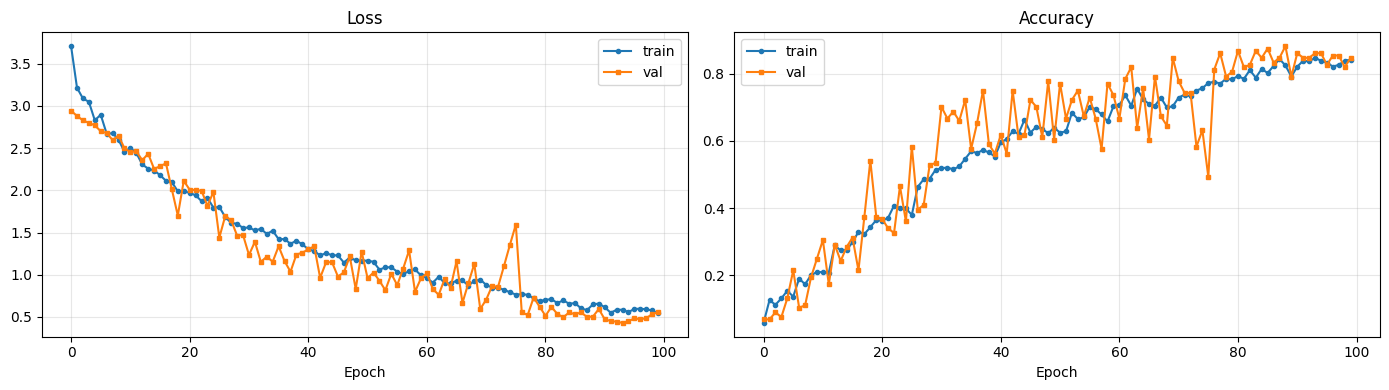


📊 Meilleure val_accuracy : 88.19%
   Meilleure val_loss     : 0.4287


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='train', marker='o', markersize=3)
axes[0].plot(history.history['val_loss'], label='val', marker='s', markersize=3)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='train', marker='o', markersize=3)
axes[1].plot(history.history['val_accuracy'], label='val', marker='s', markersize=3)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 Meilleure val_accuracy : {max(history.history["val_accuracy"]):.2%}')
print(f'   Meilleure val_loss     : {min(history.history["val_loss"]):.4f}')

In [26]:
import json
from pathlib import Path

MODEL_DIR = Path('./models')
MODEL_DIR.mkdir(exist_ok=True)

# Sauvegarde du modèle
model.save(MODEL_DIR / 'sensi_team_v1.keras')

# Sauvegarde des métadonnées (mapping classes, infos modèle)
metadata = {
    'mouvement_to_sign': my_signes,
    'sign_to_idx': sign_to_idx,
    'idx_to_sign': {str(k): v for k, v in idx_to_sign.items()},
    'n_classes': 18,
    'n_frames': 60,
    'n_features': 282,
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'best_epoch': int(np.argmax(history.history['val_accuracy']) + 1),
    'n_train': len(X_train),
    'n_val': len(X_val),
    'notes': '4 signeurs équipe, 10 prises par signeur par signe, 18 signes',
}

with open(MODEL_DIR / 'sensi_team_v1_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'✅ Modèle sauvegardé : {(MODEL_DIR / "sensi_team_v1.keras").absolute()}')
print(f'✅ Méta sauvegardée : {(MODEL_DIR / "sensi_team_v1_metadata.json").absolute()}')
print(f'\n📊 Best val_accuracy : {metadata["best_val_accuracy"]:.2%} à l\'epoch {metadata["best_epoch"]}')

✅ Modèle sauvegardé : /Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/models/sensi_team_v1.keras
✅ Méta sauvegardée : /Users/jean-christophebertincourt/code/jgriffoul-pro/sensi/models/sensi_team_v1_metadata.json

📊 Best val_accuracy : 88.19% à l'epoch 89


In [27]:
# Test sur tous les .npy d'entraînement qu'il n'a JAMAIS vus (X_val)
y_pred_probs = model.predict(X_val, verbose=0)
y_pred = y_pred_probs.argmax(axis=1)

# Accuracy globale
correct = (y_pred == y_val).sum()
print(f'Accuracy sur X_val : {correct}/{len(y_val)} = {correct/len(y_val):.1%}')

# Détail par signe
print()
from collections import defaultdict
per_class = defaultdict(lambda: [0, 0])
for true_idx, pred_idx in zip(y_val, y_pred):
    per_class[true_idx][1] += 1
    if true_idx == pred_idx:
        per_class[true_idx][0] += 1

for idx in sorted(per_class.keys()):
    c, t = per_class[idx]
    sign = idx_to_sign[idx]
    print(f'  {sign:25s} : {c:2d}/{t:2d}')

Accuracy sur X_val : 124/144 = 86.1%

  aider                     :  7/ 8
  ameliorer                 :  7/ 8
  ami                       :  5/ 8
  aujourd'hui               :  6/ 8
  bonjour                   :  6/ 8
  communiquer               :  7/ 8
  entendant                 :  7/ 8
  content                   :  5/ 8
  je_suis                   :  7/ 8
  je_veux                   :  6/ 8
  langue_des_signes         :  8/ 8
  merci                     :  8/ 8
  outil_pointage            :  8/ 8
  outil                     :  8/ 8
  presenter                 :  8/ 8
  projet                    :  6/ 8
  sourd_pointage            :  8/ 8
  sourde                    :  7/ 8


In [30]:
test_path = DATA_DIR / 'mouvement_5' / 'mouvement_5_30.npy'

# Vérifie que le fichier existe
print(f'Existe : {test_path.exists()}')
print(f'Chemin : {test_path}')

nouveau = np.load(test_path).astype(np.float32)
batch = nouveau[np.newaxis, ...]

probs = model.predict(batch, verbose=0)[0]
top_3 = np.argsort(probs)[::-1][:3]

print(f'\nFichier : {test_path.name}')
print(f'Vrai signe : bonjour')
print(f'\nTop 3 prédictions :')
for rank, idx in enumerate(top_3):
    print(f'  {rank+1}. {idx_to_sign[idx]:20s} → {probs[idx]:.1%}')

Existe : True
Chemin : /Users/jean-christophebertincourt/Desktop/Prise mouvement/mouvement_5/mouvement_5_30.npy

Fichier : mouvement_5_30.npy
Vrai signe : bonjour

Top 3 prédictions :
  1. bonjour              → 85.3%
  2. merci                → 11.3%
  3. aujourd'hui          → 1.1%
